In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
#CSV with Corrupted Images
#For Windows
#nbs = pd.read_csv('E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\NewBiasDataset\\newsmediabias_plus_combined.csv')
#for Mac
nbs = pd.read_csv('/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/newsmediabias_plus_combined.csv')





In [ ]:
nbs.head()

In [ ]:
nbs.columns

In [ ]:
nbs.dtypes

In [ ]:
nbs['multimodal_label_x'].unique()

In [ ]:
nbs['text_label_x'].unique()

In [ ]:
nbs['text_label_y'].unique()

In [ ]:
nbs.head()

In [ ]:
count = nbs['image_description_x'] == nbs['image_description_y']
count.value_counts()

Removing the columns containing url and date

In [ ]:
col = ['date_published_x','article_url','canonical_link_x','source_url_x','date_published_y','canonical_link_y','source_url_y']
nbs = nbs.drop(columns=col,axis=1)

In [ ]:
nbs.columns


In [ ]:


nbs['mac_image_path'] = '/Users/ritikrmohapatra/Downloads/images/' + nbs['image_filename'].astype(str)



In [ ]:
nbs[nbs['image_filename']=='28a35599e8.jpg'].value_counts()


In [ ]:
from PIL import Image

path = nbs.loc[nbs['image_filename']=='28a35599e8.jpg', 'mac_image_path'].values[0]

img = Image.open(path)
img.show()


In [ ]:
nbs['mac_image_path']

In [ ]:

import os
from PIL import Image

def remove_corrupted_image(path,dataset):
    path=path.replace('\\','/')
    try:
        img=Image.open(path)
        img.verify() 
        return False 
    except (IOError, SyntaxError) as e:
        print(f"Removing corrupted image: {path} - {e}")
        dataset.drop(dataset[dataset['mac_image_path'] == path].index,inplace=True)
        return True 


In [ ]:
nbs['mac_image_path'].apply(lambda x : remove_corrupted_image(x,nbs))

In [ ]:
nbs = nbs.reset_index(drop=True)


In [ ]:
nbs.shape[0]

In [ ]:
nbs.shape[0]

In [ ]:
nbs.to_csv('No_Corrupted_NBS.csv',index=False)

In [155]:
# For windows
# nbs = pd.read_csv('E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\No_Corrupted_NBS.csv')
#For Mac
nbs = pd.read_csv('/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/No_Corrupted_NBS.csv')

In [156]:
nbs.shape[0]

2185

In [157]:
nbs

,unique_id,outlet_x,title,content,image_description_x,text_label_x,multimodal_label_x,outlet_y,headline,top_image,article_text,new_categories,news_categories_confidence_scores,text_label_y,multimodal_label_y,image_description_y,image_filename,image_path,mac_image_path
0,0bad329c25,CBC.ca,South Asian newcomers to Canada say online hat...,International student Miran Kadri had many thi...,Two individuals with backpacks walking on a ci...,Likely,Unlikely,CBC.ca,South Asian newcomers to Canada say online hat...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",International student Miran Kadri had many thi...,['National' 'Opinion/Editorial'],[0.85 0.65],Likely,Unlikely,Two individuals with backpacks walking on a ci...,0bad329c25.jpeg,C:\Users\ritik\Downloads\images\images\0bad329...,/Users/ritikrmohapatra/Downloads/images/0bad32...
1,004798d706,CBC.ca,Inside Out 2: What the movie’s 4 new emotions ...,"Emotions are clues about ourselves, says exper...",A character with blue hair and a green dress s...,Likely,Unlikely,CBC.ca,Inside Out 2: What the movie’s 4 new emotions ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","Emotions are clues about ourselves, says exper...",['Entertainment' 'Health'],[0.85 0.75],Likely,Unlikely,A character with blue hair and a green dress s...,004798d706.jpeg,C:\Users\ritik\Downloads\images\images\004798d...,/Users/ritikrmohapatra/Downloads/images/004798...
2,256b487b4d,CBC.ca,Conduct hearing underway for Mountie accused o...,A police officer is facing disciplinary measur...,The image shows a close-up of a police badge w...,Unlikely,Unlikely,CBC.ca,Conduct hearing underway for Mountie accused o...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A police officer is facing disciplinary measur...,['Politics' 'National'],[0.85 0.7 ],Unlikely,Unlikely,The image shows a close-up of a police badge w...,256b487b4d.jpeg,C:\Users\ritik\Downloads\images\images\256b487...,/Users/ritikrmohapatra/Downloads/images/256b48...
3,0ca60ef164,CBC.ca,How a woman and a senator from N.L. are lobbyi...,"On a rainy day in Ottawa, Georgina McGrath's f...","A woman with blonde hair, wearing a white shir...",Likely,Unlikely,CBC.ca,How a woman and a senator from N.L. are lobbyi...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","On a rainy day in Ottawa, Georgina McGrath's f...",['Politics' 'National'],[0.9 0.8],Likely,Unlikely,"A woman with blonde hair, wearing a white shir...",0ca60ef164.jpeg,C:\Users\ritik\Downloads\images\images\0ca60ef...,/Users/ritikrmohapatra/Downloads/images/0ca60e...
4,06cc5ba548,CBC News,Unmasking of elderly U.S. spies shows there's ...,The United States has busted some spies lately...,"The image shows the seal of the CIA, featuring...",Likely,Unlikely,CBC News,Unmasking of elderly U.S. spies shows there's ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",The United States has busted some spies lately...,['National' 'Politics'],[0.9 0.85],Likely,Unlikely,"The image shows the seal of the CIA, featuring...",06cc5ba548.jpeg,C:\Users\ritik\Downloads\images\images\06cc5ba...,/Users/ritikrmohapatra/Downloads/images/06cc5b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2180,09bd0c9ab1,CNN,Biden pulls from Trump’s immigration playbook ...,A version of this story appeared in CNN’s What...,A man in a blue suit stands behind a podium wi...,Likely,Likely,CNN,Biden pulls from Trump’s immigration playbook ...,"{'bytes': None, 'path': '/projects/NMB-Plus/wh...",A version of this story appeared in CNN’s What...,['Politics' 'National'],[0.95 0.85],Likely,Likely,A man in a blue suit stands behind a podium wi...,09bd0c9ab1.jpg,C:\Users\ritik\Downloads\images\images\09bd0c9...,/Users/ritikrmohapatra/Downloads/images/09bd0c...
2181,00a45135f8,CNN,What to know about the federal gun trial Hunte...,Hunter Biden is set to stand trial Monday on f...,A man and a woman are seen walking side by sid...,Likely,Likely,CNN,What to know about the federal gun trial Hunte...,"{'bytes':

In [158]:
nbs['multimodal_label_y']


0       Unlikely
1       Unlikely
2       Unlikely
3       Unlikely
4       Unlikely
          ...   
2180      Likely
2181      Likely
2182      Likely
2183      Likely
2184      Likely
Name: multimodal_label_y, Length: 2185, dtype: object

In [159]:
nbs['mac_image_path']

0       /Users/ritikrmohapatra/Downloads/images/0bad32...
1       /Users/ritikrmohapatra/Downloads/images/004798...
2       /Users/ritikrmohapatra/Downloads/images/256b48...
3       /Users/ritikrmohapatra/Downloads/images/0ca60e...
4       /Users/ritikrmohapatra/Downloads/images/06cc5b...
                              ...                        
2180    /Users/ritikrmohapatra/Downloads/images/09bd0c...
2181    /Users/ritikrmohapatra/Downloads/images/00a451...
2182    /Users/ritikrmohapatra/Downloads/images/0471e1...
2183    /Users/ritikrmohapatra/Downloads/images/0bc2d5...
2184    /Users/ritikrmohapatra/Downloads/images/075600...
Name: mac_image_path, Length: 2185, dtype: object

In [160]:
nbs['mac_image_path'].apply(lambda x : remove_corrupted_image(x,nbs))


NameError: name 'remove_corrupted_image' is not defined

In [ ]:
nbs.shape[0]

In [ ]:
from PIL import Image

img = Image.open(nbs['mac_image_path'].iloc[1])

img.show()

In [ ]:
nbs[nbs['multimodal_label_x']!=nbs['multimodal_label_y']].value_counts().sum()

In [161]:
nbs['MultiModal_Label'] =nbs['multimodal_label_x']


In [162]:
nbs=nbs.drop(columns=['multimodal_label_x','multimodal_label_y'])

In [163]:
nbs.columns

Index(['unique_id', 'outlet_x', 'title', 'content', 'image_description_x',
       'text_label_x', 'outlet_y', 'headline', 'top_image', 'article_text',
       'new_categories', 'news_categories_confidence_scores', 'text_label_y',
       'image_description_y', 'image_filename', 'image_path', 'mac_image_path',
       'MultiModal_Label'],
      dtype='object')

In [164]:
#Renaming the columns 

In [165]:
nbs['caption']=nbs['image_description_x']

In [166]:
nbs=nbs.drop(columns=['image_description_x','image_description_y'])

In [167]:
nbs.columns

Index(['unique_id', 'outlet_x', 'title', 'content', 'text_label_x', 'outlet_y',
       'headline', 'top_image', 'article_text', 'new_categories',
       'news_categories_confidence_scores', 'text_label_y', 'image_filename',
       'image_path', 'mac_image_path', 'MultiModal_Label', 'caption'],
      dtype='object')

In [168]:
nbs['text_label_x']

0         Likely
1         Likely
2       Unlikely
3         Likely
4         Likely
          ...   
2180      Likely
2181      Likely
2182      Likely
2183      Likely
2184      Likely
Name: text_label_x, Length: 2185, dtype: object

In [169]:
nbs['text_label_y']

0         Likely
1         Likely
2       Unlikely
3         Likely
4         Likely
          ...   
2180      Likely
2181      Likely
2182      Likely
2183      Likely
2184      Likely
Name: text_label_y, Length: 2185, dtype: object

In [170]:
nbs['text_labels']=nbs['text_label_x'].apply(lambda x : 'biased' if x=='Likely' else 'non-biased')

In [171]:
nbs['MultiModal_Label']=nbs['MultiModal_Label'].apply(lambda x : 'biased' if x=='Likely' else 'non-biased')

In [172]:
nbs['text_labels']

0           biased
1           biased
2       non-biased
3           biased
4           biased
           ...    
2180        biased
2181        biased
2182        biased
2183        biased
2184        biased
Name: text_labels, Length: 2185, dtype: object

In [173]:
nbs=nbs.drop(columns=['text_label_x','text_label_y'])

In [174]:
nbs['Outlet'] = nbs['outlet_x']
nbs=nbs.drop(columns=['outlet_x','outlet_y'])

In [175]:
nbs.columns

Index(['unique_id', 'title', 'content', 'headline', 'top_image',
       'article_text', 'new_categories', 'news_categories_confidence_scores',
       'image_filename', 'image_path', 'mac_image_path', 'MultiModal_Label',
       'caption', 'text_labels', 'Outlet'],
      dtype='object')

In [176]:
nbs['new_categories'].unique()

array(["['National' 'Opinion/Editorial']", "['Entertainment' 'Health']",
       "['Politics' 'National']", "['National' 'Politics']",
       "['Local/Regional' 'National']", "['Other']",
       "['Opinion/Editorial' 'Other']", "['Entertainment' 'Other']",
       "['Local/Regional' 'Politics']", "['Politics' 'Local/Regional']",
       "['Politics' 'Opinion/Editorial']", "['Politics' 'International']",
       "['Politics' 'National' 'Entertainment']",
       "['Opinion/Editorial' 'Entertainment']", "['Entertainment']",
       "['Politics' 'Entertainment']",
       "['Entertainment' 'Opinion/Editorial']",
       "['Entertainment' 'Health' 'Technology']",
       "['Entertainment' 'Politics']",
       "['Politics' 'National' 'Opinion/Editorial']",
       "['International' 'Opinion/Editorial']", "['Politics']",
       "['Business and Finance' 'Health' 'Weather and Environment']",
       "['Technology' 'Health']", "['Other' 'Entertainment']",
       "['Politics' 'Business and Finance']",
    

[]

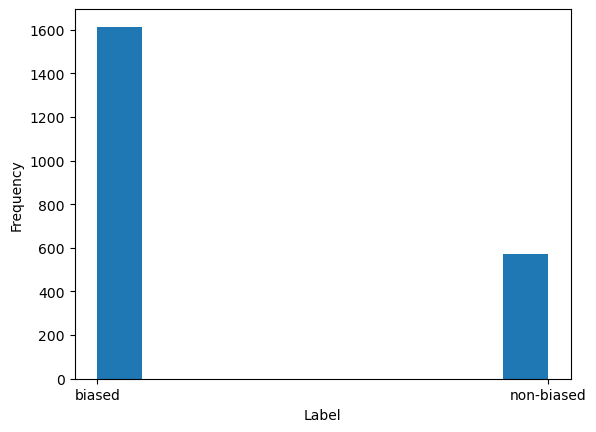

In [177]:
plt.hist(nbs['text_labels'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

[]

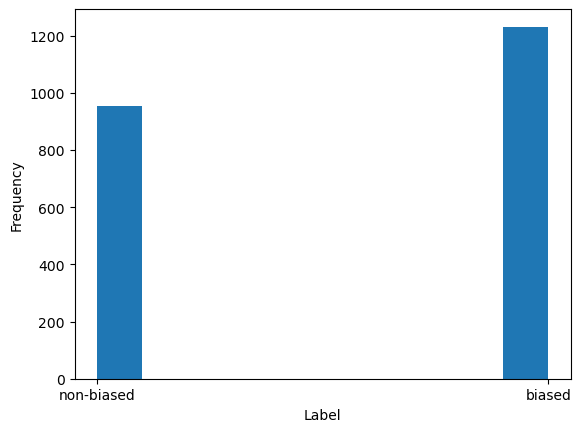

In [178]:
plt.hist(nbs['MultiModal_Label'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

In [179]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet
0,0bad329c25,South Asian newcomers to Canada say online hat...,International student Miran Kadri had many thi...,South Asian newcomers to Canada say online hat...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",International student Miran Kadri had many thi...,['National' 'Opinion/Editorial'],[0.85 0.65],0bad329c25.jpeg,C:\Users\ritik\Downloads\images\images\0bad329...,/Users/ritikrmohapatra/Downloads/images/0bad32...,non-biased,Two individuals with backpacks walking on a ci...,biased,CBC.ca
1,004798d706,Inside Out 2: What the movie’s 4 new emotions ...,"Emotions are clues about ourselves, says exper...",Inside Out 2: What the movie’s 4 new emotions ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","Emotions are clues about ourselves, says exper...",['Entertainment' 'Health'],[0.85 0.75],004798d706.jpeg,C:\Users\ritik\Downloads\images\images\004798d...,/Users/ritikrmohapatra/Downloads/images/004798...,non-biased,A character with blue hair and a green dress s...,biased,CBC.ca
2,256b487b4d,Conduct hearing underway for Mountie accused o...,A police officer is facing disciplinary measur...,Conduct hearing underway for Mountie accused o...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A police officer is facing disciplinary measur...,['Politics' 'National'],[0.85 0.7 ],256b487b4d.jpeg,C:\Users\ritik\Downloads\images\images\256b487...,/Users/ritikrmohapatra/Downloads/images/256b48...,non-biased,The image shows a close-up of a police badge w...,non-biased,CBC.ca
3,0ca60ef164,How a woman and a senator from N.L. are lobbyi...,"On a rainy day in Ottawa, Georgina McGrath's f...",How a woman and a senator from N.L. are lobbyi...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","On a rainy day in Ottawa, Georgina McGrath's f...",['Politics' 'National'],[0.9 0.8],0ca60ef164.jpeg,C:\Users\ritik\Downloads\images\images\0ca60ef...,/Users/ritikrmohapatra/Downloads/images/0ca60e...,non-biased,"A woman with blonde hair, wearing a white shir...",biased,CBC.ca
4,06cc5ba548,Unmasking of elderly U.S. spies shows there's ...,The United States has busted some spies lately...,Unmasking of elderly U.S. spies shows there's ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",The United States has busted some spies lately...,['National' 'Politics'],[0.9 0.85],06cc5ba548.jpeg,C:\Users\ritik\Downloads\images\images\06cc5ba...,/Users/ritikrmohapatra/Downloads/images/06cc5b...,non-biased,"The image shows the seal of the CIA, featuring...",biased,CBC News


In [180]:
nbs['Outlet'].unique()

array(['CBC.ca', 'CBC News', 'Breitbart', 'The Federalist',
       'Washington Examiner', 'Daily Kos', 'The Daily Beast',
       'National Review', 'ProPublica', 'The New Yorker', 'The Atlantic',
       'Newsweek', 'TIME', 'Financial Times', 'The Economist', 'CNBC',
       'HuffPost', 'Newsmax', 'The Guardian', 'The Guardian US',
       'PBS NewsHour', 'Reuters', 'Forbes', 'New York Post', 'POLITICO',
       'The Associated Press', 'USA TODAY', 'BBC.com',
       'The Washington Post', 'The New York Times', 'ABC News',
       'CBS San Francisco', 'CBS News', 'CBS Boston', 'CBS Pittsburgh',
       'CBS Miami', 'Fox News', 'CNN Underscored', 'CNN', 'National Post',
       'The Globe and Mail', 'Global News Toronto', 'Global News',
       'Global News Montréal', 'Global News Barrie',
       'Global News Edmonton', 'Global News Calgary',
       'Global News Lethbridge', 'Global News Hamilton',
       'Global News Kingston', 'Al Jazeera English', 'Bloomberg',
       'Reuters India', 'USA Tod

In [181]:
count_biasedandnonbiased_wrt_outlets=nbs.groupby(nbs['MultiModal_Label'])['Outlet'].value_counts()

In [182]:
count_biasedandnonbiased_wrt_outlets

MultiModal_Label  Outlet             
biased            Financial Times        149
                  USA TODAY              108
                  The Guardian           105
                  CNN                    103
                  The New York Times      73
                                        ... 
non-biased        Pew Research Center      1
                  RealClearPolitics        1
                  Reuters UK               1
                  The New Yorker           1
                  USA Today                1
Name: count, Length: 104, dtype: int64

In [183]:
nbs['Label_Match_Table']=nbs['MultiModal_Label']==nbs['text_labels']


In [184]:
nbs.groupby(['Label_Match_Table'])['Label_Match_Table'].value_counts()

Label_Match_Table
False     955
True     1230
Name: count, dtype: int64

In [185]:
#Here we can see that the labels for text and image+text is different in more than half of the data

In [186]:
#It would be really better if we input the model for both the text and multimodal labels are we can see that the images are also biased so there is a difference in the bias labels for the multimodal prediction

In [187]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,0bad329c25,South Asian newcomers to Canada say online hat...,International student Miran Kadri had many thi...,South Asian newcomers to Canada say online hat...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",International student Miran Kadri had many thi...,['National' 'Opinion/Editorial'],[0.85 0.65],0bad329c25.jpeg,C:\Users\ritik\Downloads\images\images\0bad329...,/Users/ritikrmohapatra/Downloads/images/0bad32...,non-biased,Two individuals with backpacks walking on a ci...,biased,CBC.ca,False
1,004798d706,Inside Out 2: What the movie’s 4 new emotions ...,"Emotions are clues about ourselves, says exper...",Inside Out 2: What the movie’s 4 new emotions ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","Emotions are clues about ourselves, says exper...",['Entertainment' 'Health'],[0.85 0.75],004798d706.jpeg,C:\Users\ritik\Downloads\images\images\004798d...,/Users/ritikrmohapatra/Downloads/images/004798...,non-biased,A character with blue hair and a green dress s...,biased,CBC.ca,False
2,256b487b4d,Conduct hearing underway for Mountie accused o...,A police officer is facing disciplinary measur...,Conduct hearing underway for Mountie accused o...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",A police officer is facing disciplinary measur...,['Politics' 'National'],[0.85 0.7 ],256b487b4d.jpeg,C:\Users\ritik\Downloads\images\images\256b487...,/Users/ritikrmohapatra/Downloads/images/256b48...,non-biased,The image shows a close-up of a police badge w...,non-biased,CBC.ca,True
3,0ca60ef164,How a woman and a senator from N.L. are lobbyi...,"On a rainy day in Ottawa, Georgina McGrath's f...",How a woman and a senator from N.L. are lobbyi...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...","On a rainy day in Ottawa, Georgina McGrath's f...",['Politics' 'National'],[0.9 0.8],0ca60ef164.jpeg,C:\Users\ritik\Downloads\images\images\0ca60ef...,/Users/ritikrmohapatra/Downloads/images/0ca60e...,non-biased,"A woman with blonde hair, wearing a white shir...",biased,CBC.ca,False
4,06cc5ba548,Unmasking of elderly U.S. spies shows there's ...,The United States has busted some spies lately...,Unmasking of elderly U.S. spies shows there's ...,"{'bytes': None, 'path': '/projects/NMB-Plus/ra...",The United States has busted some spies lately...,['National' 'Politics'],[0.9 0.85],06cc5ba548.jpeg,C:\Users\ritik\Downloads\images\images\06cc5ba...,/Users/ritikrmohapatra/Downloads/images/06cc5b...,non-biased,"The image shows the seal of the CIA, featuring...",biased,CBC News,False


In [188]:
len(nbs['Outlet'].unique())


61

In [189]:
nbs['Outlet'].value_counts()

Outlet
Financial Times         278
USA TODAY               176
CNN                     165
The Guardian            161
The New York Times      146
                       ... 
Global News Montréal      1
CBS Miami                 1
CBS Pittsburgh            1
CBS San Francisco         1
Reuters UK                1
Name: count, Length: 61, dtype: int64

In [190]:
dataset_for_plotting_text_labels = nbs[['text_labels','Outlet']]
dataset_for_plotting_MultiModal_Label = nbs[['MultiModal_Label','Outlet']]

In [191]:
dataset_for_plotting_MultiModal_Label.head()


,MultiModal_Label,Outlet
0,non-biased,CBC.ca
1,non-biased,CBC.ca
2,non-biased,CBC.ca
3,non-biased,CBC.ca
4,non-biased,CBC News


In [192]:
dataset_for_plotting_MultiModal_Label.shape[0]

2185

In [193]:
dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet'] == 'CBC.ca']

,MultiModal_Label,Outlet
0,non-biased,CBC.ca
1,non-biased,CBC.ca
2,non-biased,CBC.ca
3,non-biased,CBC.ca
5,non-biased,CBC.ca
6,non-biased,CBC.ca
7,non-biased,CBC.ca
8,non-biased,CBC.ca
9,non-biased,CBC.ca
10,non-biased,CBC.ca


In [194]:
for i in dataset_for_plotting_MultiModal_Label['Outlet'].unique():
    dataset_for_plotting_MultiModal_Label = dataset_for_plotting_MultiModal_Label.groupby('Outlet').filter(lambda x: len(x) >= 100)


In [195]:
for i in dataset_for_plotting_text_labels['Outlet'].unique():
    dataset_for_plotting_text_labels = dataset_for_plotting_text_labels.groupby('Outlet').filter(lambda x: len(x) >= 100)


In [196]:
dataset_for_plotting_MultiModal_Label.shape[0]

1268

In [197]:
len(dataset_for_plotting_MultiModal_Label['Outlet'].unique())

8

In [198]:

dataset_for_plotting_text_labels

,text_labels,Outlet
87,biased,Financial Times
88,biased,Financial Times
89,non-biased,Financial Times
90,biased,Financial Times
91,biased,Financial Times
...,...,...
2180,biased,CNN
2181,biased,CNN
2182,biased,CNN
2183,biased,CNN


[]

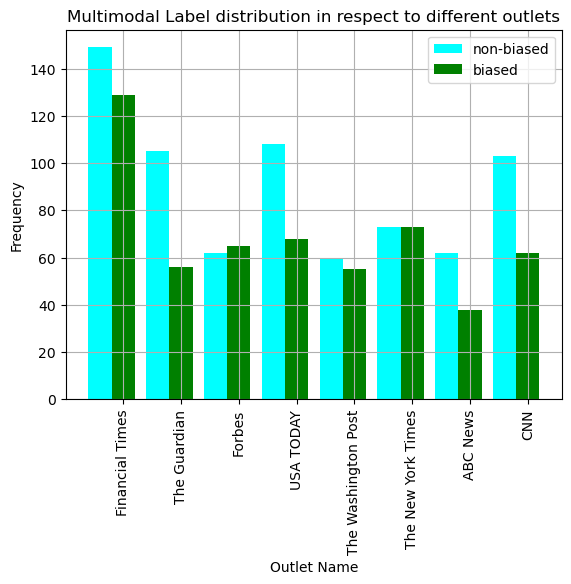

In [199]:

topic=dataset_for_plotting_MultiModal_Label['Outlet'].unique()
x= np.arange(len(topic))


width=0.4
for i in x:
    plt.bar(i-0.4, (dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet']==topic[i]]['MultiModal_Label'] == 'biased').sum(), width, color='cyan')
    plt.bar(i, (dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet']==topic[i]]['MultiModal_Label'] == 'non-biased').sum(), width, color='green')
plt.xticks(x,topic,rotation='vertical')
plt.legend(nbs['MultiModal_Label'].unique())
plt.xlabel('Outlet Name')
plt.ylabel('Frequency')
plt.title('Multimodal Label distribution in respect to different outlets')
plt.grid(True)
plt.plot()

[]

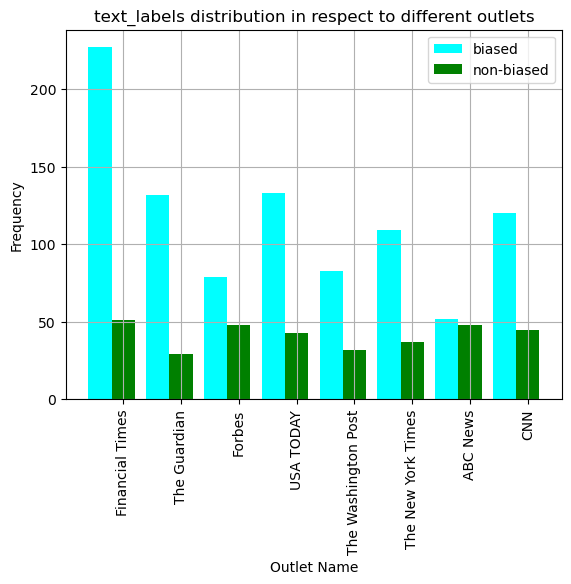

In [200]:
topic=dataset_for_plotting_text_labels['Outlet'].unique()
x= np.arange(len(topic))

width=0.4
for i in x:
    plt.bar(i-0.4, (dataset_for_plotting_text_labels[dataset_for_plotting_text_labels['Outlet']==topic[i]]['text_labels'] == 'biased').sum(), width, color='cyan')
    plt.bar(i, (dataset_for_plotting_text_labels[dataset_for_plotting_text_labels['Outlet']==topic[i]]['text_labels'] == 'non-biased').sum(), width, color='green')
plt.xticks(x,topic,rotation='vertical')
plt.legend(nbs['text_labels'].unique())
plt.xlabel('Outlet Name')
plt.ylabel('Frequency')
plt.title('text_labels distribution in respect to different outlets')
plt.grid(True)
plt.plot()

nbs.columns

Removing non words 

In [201]:
nbs['article_text'] = nbs['article_text'].replace(to_replace=r'[^\w\s]', value='', regex=True)
nbs['caption'] = nbs['caption'].replace(to_replace=r'[^\w\s]', value='', regex=True)


Lower casing the text

In [202]:
nbs = nbs.applymap(lambda x: x.lower() if isinstance(x, str) else x)


/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3422254871.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  nbs = nbs.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [203]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,/users/ritikrmohapatra/downloads/images/0bad32...,non-biased,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
1,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,/users/ritikrmohapatra/downloads/images/004798...,non-biased,a character with blue hair and a green dress s...,biased,cbc.ca,False
2,256b487b4d,conduct hearing underway for mountie accused o...,a police officer is facing disciplinary measur...,conduct hearing underway for mountie accused o...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a police officer is facing disciplinary measur...,['politics' 'national'],[0.85 0.7 ],256b487b4d.jpeg,c:\users\ritik\downloads\images\images\256b487...,/users/ritikrmohapatra/downloads/images/256b48...,non-biased,the image shows a closeup of a police badge wi...,non-biased,cbc.ca,True
3,0ca60ef164,how a woman and a senator from n.l. are lobbyi...,"on a rainy day in ottawa, georgina mcgrath's f...",how a woman and a senator from n.l. are lobbyi...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",on a rainy day in ottawa georgina mcgraths foo...,['politics' 'national'],[0.9 0.8],0ca60ef164.jpeg,c:\users\ritik\downloads\images\images\0ca60ef...,/users/ritikrmohapatra/downloads/images/0ca60e...,non-biased,a woman with blonde hair wearing a white shirt...,biased,cbc.ca,False
4,06cc5ba548,unmasking of elderly u.s. spies shows there's ...,the united states has busted some spies lately...,unmasking of elderly u.s. spies shows there's ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the united states has busted some spies lately...,['national' 'politics'],[0.9 0.85],06cc5ba548.jpeg,c:\users\ritik\downloads\images\images\06cc5ba...,/users/ritikrmohapatra/downloads/images/06cc5b...,non-biased,the image shows the seal of the cia featuring ...,biased,cbc news,False


In [204]:
nbs.describe()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
count,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185,2185
unique,2185,2185,2185,2185,2185,2185,256,116,2185,2185,2185,2,2165,2,60,2
top,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['politics' 'national'],[0.95 0.85],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,/users/ritikrmohapatra/downloads/images/0bad32...,biased,the new york times logo centered on a black ba...,biased,financial times,True
freq,1,1,1,1,1,1,644,544,1,1,1,1231,15,1614,278,1230


In [205]:
nbs.isna().sum()

unique_id                            0
title                                0
content                              0
headline                             0
top_image                            0
article_text                         0
new_categories                       0
news_categories_confidence_scores    0
image_filename                       0
image_path                           0
mac_image_path                       0
MultiModal_Label                     0
caption                              0
text_labels                          0
Outlet                               0
Label_Match_Table                    0
dtype: int64

In [206]:
nbs.shape[0]

2185

In [207]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,/users/ritikrmohapatra/downloads/images/0bad32...,non-biased,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
1,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,/users/ritikrmohapatra/downloads/images/004798...,non-biased,a character with blue hair and a green dress s...,biased,cbc.ca,False
2,256b487b4d,conduct hearing underway for mountie accused o...,a police officer is facing disciplinary measur...,conduct hearing underway for mountie accused o...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a police officer is facing disciplinary measur...,['politics' 'national'],[0.85 0.7 ],256b487b4d.jpeg,c:\users\ritik\downloads\images\images\256b487...,/users/ritikrmohapatra/downloads/images/256b48...,non-biased,the image shows a closeup of a police badge wi...,non-biased,cbc.ca,True
3,0ca60ef164,how a woman and a senator from n.l. are lobbyi...,"on a rainy day in ottawa, georgina mcgrath's f...",how a woman and a senator from n.l. are lobbyi...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",on a rainy day in ottawa georgina mcgraths foo...,['politics' 'national'],[0.9 0.8],0ca60ef164.jpeg,c:\users\ritik\downloads\images\images\0ca60ef...,/users/ritikrmohapatra/downloads/images/0ca60e...,non-biased,a woman with blonde hair wearing a white shirt...,biased,cbc.ca,False
4,06cc5ba548,unmasking of elderly u.s. spies shows there's ...,the united states has busted some spies lately...,unmasking of elderly u.s. spies shows there's ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the united states has busted some spies lately...,['national' 'politics'],[0.9 0.85],06cc5ba548.jpeg,c:\users\ritik\downloads\images\images\06cc5ba...,/users/ritikrmohapatra/downloads/images/06cc5b...,non-biased,the image shows the seal of the cia featuring ...,biased,cbc news,False


In [208]:
nbs['image_path'][1].replace('\\','/')

'c:/users/ritik/downloads/images/images/004798d706.jpeg'

In [209]:
#This dataset shows that the multimodal bias distribution has a leaning towards being biased a little biased.And we can also see that text labels and multimodal labels differ a bit and it can also be infered that the images affect the bias classification of the article .
#

In [210]:
nbs.columns

Index(['unique_id', 'title', 'content', 'headline', 'top_image',
       'article_text', 'new_categories', 'news_categories_confidence_scores',
       'image_filename', 'image_path', 'mac_image_path', 'MultiModal_Label',
       'caption', 'text_labels', 'Outlet', 'Label_Match_Table'],
      dtype='object')

In [211]:
nbs['new_categories']

0       ['national' 'opinion/editorial']
1             ['entertainment' 'health']
2                ['politics' 'national']
3                ['politics' 'national']
4                ['national' 'politics']
                      ...               
2180             ['politics' 'national']
2181             ['politics' 'national']
2182    ['opinion/editorial' 'politics']
2183        ['national' 'international']
2184        ['politics' 'international']
Name: new_categories, Length: 2185, dtype: object

In [212]:
nbs.head()

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,/users/ritikrmohapatra/downloads/images/0bad32...,non-biased,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
1,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,/users/ritikrmohapatra/downloads/images/004798...,non-biased,a character with blue hair and a green dress s...,biased,cbc.ca,False
2,256b487b4d,conduct hearing underway for mountie accused o...,a police officer is facing disciplinary measur...,conduct hearing underway for mountie accused o...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a police officer is facing disciplinary measur...,['politics' 'national'],[0.85 0.7 ],256b487b4d.jpeg,c:\users\ritik\downloads\images\images\256b487...,/users/ritikrmohapatra/downloads/images/256b48...,non-biased,the image shows a closeup of a police badge wi...,non-biased,cbc.ca,True
3,0ca60ef164,how a woman and a senator from n.l. are lobbyi...,"on a rainy day in ottawa, georgina mcgrath's f...",how a woman and a senator from n.l. are lobbyi...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",on a rainy day in ottawa georgina mcgraths foo...,['politics' 'national'],[0.9 0.8],0ca60ef164.jpeg,c:\users\ritik\downloads\images\images\0ca60ef...,/users/ritikrmohapatra/downloads/images/0ca60e...,non-biased,a woman with blonde hair wearing a white shirt...,biased,cbc.ca,False
4,06cc5ba548,unmasking of elderly u.s. spies shows there's ...,the united states has busted some spies lately...,unmasking of elderly u.s. spies shows there's ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the united states has busted some spies lately...,['national' 'politics'],[0.9 0.85],06cc5ba548.jpeg,c:\users\ritik\downloads\images\images\06cc5ba...,/users/ritikrmohapatra/downloads/images/06cc5b...,non-biased,the image shows the seal of the cia featuring ...,biased,cbc news,False


In [213]:
nbs.isna().sum()

unique_id                            0
title                                0
content                              0
headline                             0
top_image                            0
article_text                         0
new_categories                       0
news_categories_confidence_scores    0
image_filename                       0
image_path                           0
mac_image_path                       0
MultiModal_Label                     0
caption                              0
text_labels                          0
Outlet                               0
Label_Match_Table                    0
dtype: int64

In [214]:
nbs['MultiModal_Label'] = nbs['MultiModal_Label'].apply(lambda x: 1 if x == 'biased' else 0)

In [215]:
nbs['MultiModal_Label'].describe()

count    2185.000000
mean        0.563387
std         0.496079
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: MultiModal_Label, dtype: float64

In [216]:
nbs.shape[0]


2185

In [217]:
nbs

,unique_id,title,content,headline,top_image,article_text,new_categories,news_categories_confidence_scores,image_filename,image_path,mac_image_path,MultiModal_Label,caption,text_labels,Outlet,Label_Match_Table
0,0bad329c25,south asian newcomers to canada say online hat...,international student miran kadri had many thi...,south asian newcomers to canada say online hat...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",international student miran kadri had many thi...,['national' 'opinion/editorial'],[0.85 0.65],0bad329c25.jpeg,c:\users\ritik\downloads\images\images\0bad329...,/users/ritikrmohapatra/downloads/images/0bad32...,0,two individuals with backpacks walking on a ci...,biased,cbc.ca,False
1,004798d706,inside out 2: what the movie’s 4 new emotions ...,"emotions are clues about ourselves, says exper...",inside out 2: what the movie’s 4 new emotions ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",emotions are clues about ourselves says expert...,['entertainment' 'health'],[0.85 0.75],004798d706.jpeg,c:\users\ritik\downloads\images\images\004798d...,/users/ritikrmohapatra/downloads/images/004798...,0,a character with blue hair and a green dress s...,biased,cbc.ca,False
2,256b487b4d,conduct hearing underway for mountie accused o...,a police officer is facing disciplinary measur...,conduct hearing underway for mountie accused o...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",a police officer is facing disciplinary measur...,['politics' 'national'],[0.85 0.7 ],256b487b4d.jpeg,c:\users\ritik\downloads\images\images\256b487...,/users/ritikrmohapatra/downloads/images/256b48...,0,the image shows a closeup of a police badge wi...,non-biased,cbc.ca,True
3,0ca60ef164,how a woman and a senator from n.l. are lobbyi...,"on a rainy day in ottawa, georgina mcgrath's f...",how a woman and a senator from n.l. are lobbyi...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",on a rainy day in ottawa georgina mcgraths foo...,['politics' 'national'],[0.9 0.8],0ca60ef164.jpeg,c:\users\ritik\downloads\images\images\0ca60ef...,/users/ritikrmohapatra/downloads/images/0ca60e...,0,a woman with blonde hair wearing a white shirt...,biased,cbc.ca,False
4,06cc5ba548,unmasking of elderly u.s. spies shows there's ...,the united states has busted some spies lately...,unmasking of elderly u.s. spies shows there's ...,"{'bytes': none, 'path': '/projects/nmb-plus/ra...",the united states has busted some spies lately...,['national' 'politics'],[0.9 0.85],06cc5ba548.jpeg,c:\users\ritik\downloads\images\images\06cc5ba...,/users/ritikrmohapatra/downloads/images/06cc5b...,0,the image shows the seal of the cia featuring ...,biased,cbc news,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2180,09bd0c9ab1,biden pulls from trump’s immigration playbook ...,a version of this story appeared in cnn’s what...,biden pulls from trump’s immigration playbook ...,"{'bytes': none, 'path': '/projects/nmb-plus/wh...",a version of this story appeared in cnns what ...,['politics' 'national'],[0.95 0.85],09bd0c9ab1.jpg,c:\users\ritik\downloads\images\images\09bd0c9...,/users/ritikrmohapatra/downloads/images/09bd0c...,1,a man in a blue suit stands behind a podium wi...,biased,cnn,True
2181,00a45135f8,what to know about the federal gun trial hunte...,hunter biden is set to stand trial monday on f...,what to know about the federal gun trial hunte...,"{'bytes': none, 'path': '/projects/nmb-plus/wh...",hunter biden is set to stand trial monday on f...,['politics' 'national'],[0.95 0.9 ],00a45135f8.jpg,c:\users\ritik\downloads\images\images\00a4513...,/users/ritikrmohapatra/downloads/images/00a451...,1,a man and a woman are seen walking side by sid...,biased,cnn,True
2182,0471e108dd,opinion: we germans are making trump ‘thunders...,editor’s note: anna sauerbrey is the foreign e...,opinion: we germans are making trump ‘thunders...,"{'bytes': none, 'path': '/projects/nmb-plus/wh...",editors note anna sauerbrey is the foreign edi...,['opinion/editoria

In [218]:
nbs_=nbs.iloc[:1299]

In [219]:
nbs_=nbs_[['caption','MultiModal_Label','mac_image_path']]
nbs_.rename(columns={
    'caption': 'caption',
    'MultiModal_Label': 'MultiModal_Label',
    'mac_image_path': 'image_path' 
},inplace=True)


'''Change the quntity of data'''

In [220]:
nbs_

,caption,MultiModal_Label,image_path
0,two individuals with backpacks walking on a ci...,0,/users/ritikrmohapatra/downloads/images/0bad32...
1,a character with blue hair and a green dress s...,0,/users/ritikrmohapatra/downloads/images/004798...
2,the image shows a closeup of a police badge wi...,0,/users/ritikrmohapatra/downloads/images/256b48...
3,a woman with blonde hair wearing a white shirt...,0,/users/ritikrmohapatra/downloads/images/0ca60e...
4,the image shows the seal of the cia featuring ...,0,/users/ritikrmohapatra/downloads/images/06cc5b...
...,...,...,...
1294,the image shows the iconic eiffel tower with t...,1,/users/ritikrmohapatra/downloads/images/014241...
1295,a man in a blue and gold costume stands confid...,0,/users/ritikrmohapatra/downloads/images/1c7da5...
1296,a flooded street with fallen trees and a damag...,1,/users/ritikrmohapatra/downloads/images/003354...
1297,a man stands at a podium with a microphone sur...,0,/users/ritikrmohapatra/downloads/images/0809ad...


[]

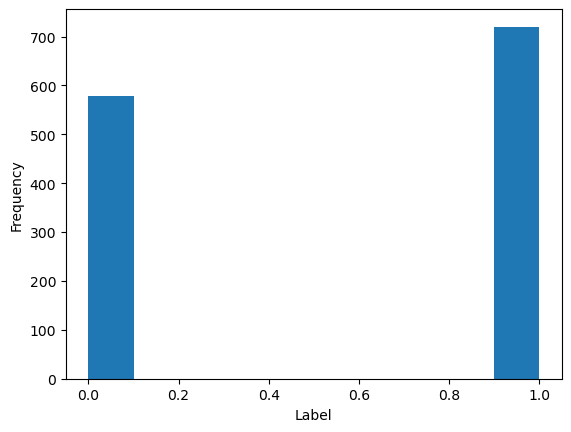

In [221]:
plt.hist(nbs_['MultiModal_Label'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

In [222]:
#nbs_text_and_image = nbs.drop(columns=['unique_id'])

Train Test Split

In [288]:

X_train, X_test = train_test_split(nbs_, test_size=0.2, random_state=42, stratify=nbs_['MultiModal_Label'])


In [289]:
X_train['MultiModal_Label'].value_counts()

MultiModal_Label
1    576
0    463
Name: count, dtype: int64

Function for Data Processing

In [290]:
X_test['MultiModal_Label'].value_counts()

MultiModal_Label
1    144
0    116
Name: count, dtype: int64

In [291]:
#def Data_Processing(Dataset,Multilabel_column):
    

Importing the pretrained multimodal model from huggin face that is trained on NBS+ Dataset

Ref : https://huggingface.co/maximuspowers/multimodal-bias-classifier

In [292]:
import torch
from torch import nn
from transformers import BertModel,AutoModel
from huggingface_hub import hf_hub_download
from typing import Literal
import json
class MultimodalClassifier(nn.Module):
    def __init__(
            self,
            text_encoder_id_or_path: str,
            image_encoder_id_or_path: str,
            projection_dim: int,
            proj_dropout: float = 0.1,
            fusion_dropout: float = 0.1,
            num_classes: int = 1,
            num_attention_heads=8
            
        ) -> None:
        super().__init__()

        self.projection_dim = projection_dim
        self.num_classes = num_classes

        self.text_encoder = BertModel.from_pretrained(text_encoder_id_or_path)
        self.text_projection = nn.Sequential(
            nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
            nn.ReLU(),
            nn.Dropout(proj_dropout),
            nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
            nn.ReLU(),
            nn.Dropout(proj_dropout),
        )

        self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
        self.image_encoder.classifier = nn.Identity()  # rm the classification head
        self.image_projection = nn.Sequential(
            nn.Linear(512, self.projection_dim),
            nn.ReLU(),
            nn.Dropout(proj_dropout),
            nn.Linear(self.projection_dim, self.projection_dim),
            nn.ReLU(),
            nn.Dropout(proj_dropout),
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=projection_dim,
            num_heads=num_attention_heads,
            batch_first=True
        )
        

        ##### Classification Layer
        self.classifier = nn.Linear(self.projection_dim, self.num_classes)
        self.dropout = nn.Dropout(fusion_dropout)


    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
        full_text_features = self.text_projection(full_text_features)

        image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state  
        B, C, H, W = image_features.shape
        image_features = image_features.view(B, C, H*W).permute(0, 2, 1)  
        image_features = self.image_projection(image_features) 

        attended_text, _ = self.cross_attention(
            query=full_text_features,   
            key=image_features,    
            value=image_features   
        )

        cls_rep = attended_text[:, 0, :]
        cls_rep = self.dropout(cls_rep)
        logits = self.classifier(cls_rep)

        return logits

def load_model(drop_proj=0.1,drop_fus=0.1):
    
    config = {
        "model_type": "multimodal-bias-classifier", 
        #"text_encoder_id_or_path": "E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\Model_config", #For Windows
        "text_encoder_id_or_path": "/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config",
        "image_encoder_id_or_path": "resnet34", 
        "projection_dim": 768, 
        "num_classes": 1,
        "hidden_size": 768, 
        "save_components": ["resnet_encoder", "text_encoder", "fusion_layer", "classifier"], 
        "exclude_components": ["clip_text_encoder", "clip_image_encoder"]}
    model = MultimodalClassifier(
        text_encoder_id_or_path=config["text_encoder_id_or_path"],
        image_encoder_id_or_path="microsoft/resnet-34",
        projection_dim=config["projection_dim"],
        proj_dropout=drop_proj,
        fusion_dropout=drop_fus,
        num_classes=config["num_classes"]
    )

    model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
    checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu')) #wINDOWS 

    model.load_state_dict(checkpoint, strict=False)

    return model


Declaring Tokenizer

In [293]:
import torch
from transformers import AutoTokenizer
from PIL import Image
import requests
from torchvision import transforms

model = load_model()
model.eval()





Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [294]:
print(model)

MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [295]:
!pip install torchinfo

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [296]:
import torchinfo

torchinfo.summary(model, col_names = ["num_params", "params_percent", "trainable"], depth = 4, row_settings = ["var_names"], verbose = 1);


Layer (type (var_name))                                                     Param #                   Param %                   Trainable
MultimodalClassifier (MultimodalClassifier)                                 --                             --                   True
├─BertModel (text_encoder)                                                  --                             --                   True
│    └─BertEmbeddings (embeddings)                                          --                             --                   True
│    │    └─Embedding (word_embeddings)                                     23,440,896                 25.27%                   True
│    │    └─Embedding (position_embeddings)                                 393,216                     0.42%                   True
│    │    └─Embedding (token_type_embeddings)                               1,536                       0.00%                   True
│    │    └─LayerNorm (LayerNorm)                               

In [297]:
model.classifier

Linear(in_features=768, out_features=1, bias=True)

In [298]:
device = torch.device(device = "cuda" if torch.cuda.is_available() else "cpu") #Windows GPU


model.to(device)

MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

Dataloader

In [307]:
text_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(size=224, scale=(0.7, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.7),                  
    transforms.ColorJitter(brightness=0.1, contrast=0.2, saturation=0.9, hue=0.3),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [308]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class DATA(Dataset):
    def __init__(self, dataframe, text_tokenizer, image_transform):
        self.df = dataframe
        self.text_tokenizer = text_tokenizer
        self.image_transform = image_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['caption']
        image_path = row['image_path']

        # tokenize text
        text_inputs = self.text_tokenizer(
            text, padding='max_length', truncation=True, max_length=512 , return_tensors='pt'
        )
        # transform image
        image = Image.open(image_path).convert('RGB')
        image_input = self.image_transform(image)

        #label = torch.tensor(row['MultiModal_Label'])
        
        input_ids= text_inputs['input_ids'][0]
        attention_mask= text_inputs['attention_mask']
        pixel_values = image_input
        labels =  int(row['MultiModal_Label'])
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'pixel_values': image_input,
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Then create dataset and loader

train_loader_dataset = DATA(X_train, text_tokenizer, image_transform)
test_loader_dataset = DATA(X_test, text_tokenizer, image_transform)

training_loader = DataLoader(train_loader_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(test_loader_dataset, batch_size=8, shuffle=True)

In [309]:
train_loader_dataset

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [310]:
import torch
torch.cuda.empty_cache()

In [311]:
from tqdm import tqdm

loss_function = torch.nn.BCEWithLogitsLoss()
LEARNING_RATE=2e-5




def calcuate_accuracy(preds, targets):
    n_correct = (preds==targets).sum().item()
    return n_correct

def calculate_truth_value(preds,targets):
    n_True_pos = ((preds==targets)&(targets==1)).sum().item()
    n_False_pos = ((preds!=targets)&(targets==0)).sum().item()
    n_True_neg = ((preds==targets)&(targets==0)).sum().item()
    n_False_neg = ((preds!=targets)&(targets==1)).sum().item()
    return n_True_pos,n_False_pos,n_True_neg,n_False_neg

def train(epoch, training_loader,LEARNING_RATE=2e-5,threshold=0.5):

    optimizer = torch.optim.Adam(params =  model.parameters(), lr=LEARNING_RATE)

    tr_loss = 0
    n_correct = 0
    nb_tr_steps = 0
    nb_tr_examples = 0
    True_pos= 0 
    False_pos=0
    True_neg=0
    False_neg=0
    n_True_pos=0;n_False_pos=0;n_True_neg=0;n_False_neg=0
    model.train()
    for _,data in tqdm(enumerate(training_loader, 0)):
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        pixel_values = data['pixel_values'].to(device, dtype = torch.float)
        targets = data['labels'][:, None].to(device, dtype = torch.float)

        outputs = model(input_ids=ids,
            attention_mask=mask,
            pixel_values=pixel_values)
        loss = loss_function(outputs, targets)
        tr_loss += loss.item()
        preds = torch.sigmoid(outputs) > threshold        
        n_correct += calcuate_accuracy(preds, targets.bool())

        n_True_pos,n_False_pos,n_True_neg,n_False_neg = calculate_truth_value(preds, targets.bool())
        True_pos += n_True_pos
        False_pos += n_False_pos
        True_neg += n_True_neg
        False_neg += n_False_neg

        nb_tr_steps += 1
        nb_tr_examples+=targets.size(0)
        
        if _%500==0:
            loss_step = tr_loss/nb_tr_steps
            accu_step = (n_correct*100)/nb_tr_examples 

        optimizer.zero_grad()
        loss.backward()
        # # When using GPU
        optimizer.step()

    
    epoch_loss = tr_loss/nb_tr_steps
    epoch_accu = (n_correct*100)/nb_tr_examples
    print(f'The Total Accuracy for TRaining Epoch {epoch}:{epoch_accu}')

    return model,epoch_accu,epoch_loss
 



def valid(model, testing_loader,threshold=0.5):
    model.eval()
    n_correct = 0; n_wrong = 0; total = 0; tr_loss=0; nb_tr_steps=0; nb_tr_examples=0 ; True_pos=0; False_pos=0; True_neg=0; False_neg=0; n_True_pos=0;n_False_pos=0;n_True_neg=0;n_False_neg=0
    all_preds=[]
    all_targets=[]
    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            pixel_values = data['pixel_values'].to(device, dtype = torch.float)
            targets = data['labels'].reshape(-1,1).to(device, dtype = torch.float)

            all_targets.append(targets.bool())

            outputs = model(input_ids=ids,
            attention_mask=mask,
            pixel_values=pixel_values)

            loss = loss_function(outputs, targets)
            tr_loss += loss.item()
            preds = torch.sigmoid(outputs) > threshold
            all_preds.append(preds)

            n_correct += calcuate_accuracy(preds, targets.bool())

            n_True_pos,n_False_pos,n_True_neg,n_False_neg = calculate_truth_value(preds, targets)
            True_pos += n_True_pos
            False_pos += n_False_pos
            True_neg += n_True_neg
            False_neg += n_False_neg


            nb_tr_steps += 1
            nb_tr_examples+=targets.size(0)
            
            if _%5000==0:
                loss_step = tr_loss/nb_tr_steps
                accu_step = (n_correct*100)/nb_tr_examples

    

    epoch_loss = tr_loss/nb_tr_steps
    epoch_accu = (n_correct*100)/nb_tr_examples
    
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_targets = torch.cat(all_targets).cpu().numpy()

    return epoch_accu,True_pos,False_pos,True_neg,False_neg,epoch_loss,all_preds,all_targets

#https://stackoverflow.com/questions/62301674/extracting-labels-after-applying-softmax  --> For Probability, Weights and Labels

In [312]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(all_targets,all_pred):
    cm = confusion_matrix(all_targets, all_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    plt.figure(figsize=(6,6))
    disp.plot(cmap=plt.cm.Blues, values_format='d')  
    plt.title("Confusion Matrix")
    plt.show()

In [313]:
def eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg):                                      
    recall_deno = n_True_pos+n_False_neg                               
    recall = n_True_pos/recall_deno
    print(f"Recall : {recall}")

    Precision_dino = n_True_pos + n_False_pos                                                                                                                                                  
    Precision = n_True_pos/Precision_dino             
    print(f"Precision : {Precision}")                                                                                            
    F1_dino = Precision+recall
    F1_num= 2*Precision*recall
    F1= F1_num/F1_dino
    print(f"F1 : {F1}")

    return F1

0it [00:00, ?it/s]/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),
/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
130it [08:03,  3.72s/it]


The Total Accuracy for TRaining Epoch 0:55.82290664100096
Epoch 0:
Training Accuracy : 55.82290664100096
Training Loss : 0.6836983446891491


33it [00:32,  1.02it/s]

validation Accuracy : 55.38461538461539
validation Loss : 0.6736188567045963
True Positives : 144
n_False_pos : 116
n_True_neg : 0
n_False_neg : 0


<Figure size 600x600 with 0 Axes>

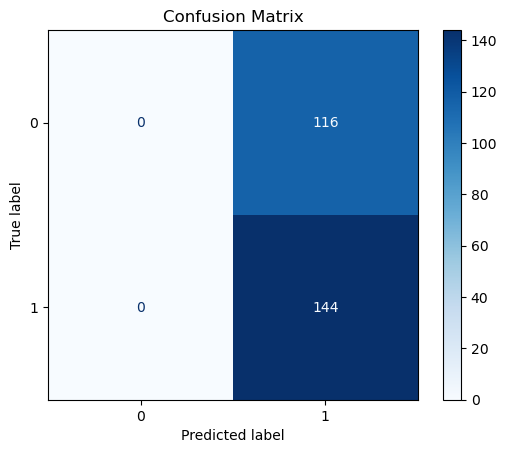

Recall : 1.0
Precision : 0.5538461538461539
F1 : 0.712871287128713
F1 Score: 0.712871287128713


0it [00:00, ?it/s]/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),
/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
130it [07:56,  3.66s/it]


The Total Accuracy for TRaining Epoch 1:59.384023099133785
Epoch 1:
Training Accuracy : 59.384023099133785
Training Loss : 0.6671601212941684


33it [00:33,  1.03s/it]

validation Accuracy : 57.69230769230769
validation Loss : 0.668587681018945
True Positives : 138
n_False_pos : 104
n_True_neg : 12
n_False_neg : 6


<Figure size 600x600 with 0 Axes>

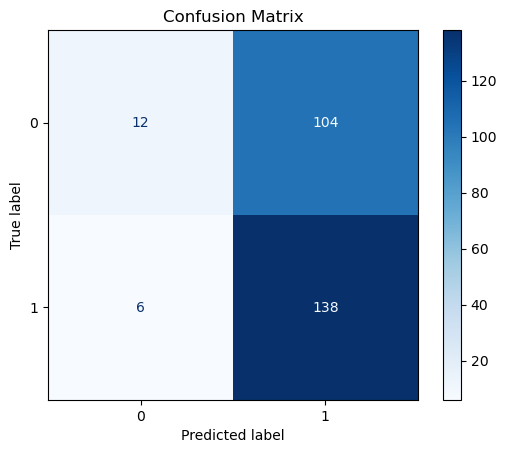

Recall : 0.9583333333333334
Precision : 0.5702479338842975
F1 : 0.7150259067357513
F1 Score: 0.7150259067357513


0it [00:00, ?it/s]/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),
/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
130it [08:57,  4.14s/it]


The Total Accuracy for TRaining Epoch 2:64.29258902791145
Epoch 2:
Training Accuracy : 64.29258902791145
Training Loss : 0.6247503464038555


33it [00:45,  1.38s/it]

validation Accuracy : 56.53846153846154
validation Loss : 0.6821591619289282
True Positives : 89
n_False_pos : 58
n_True_neg : 58
n_False_neg : 55


<Figure size 600x600 with 0 Axes>

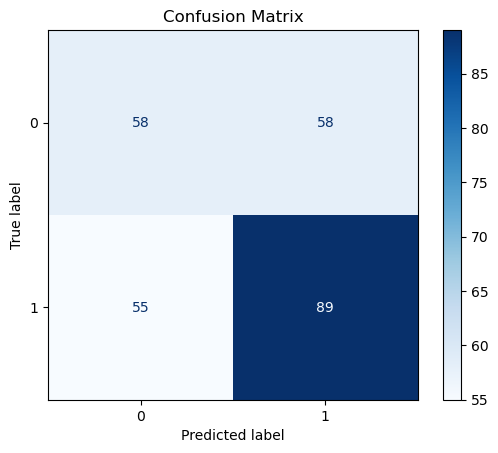

Recall : 0.6180555555555556
Precision : 0.6054421768707483
F1 : 0.6116838487972508
F1 Score: 0.6116838487972508


In [314]:
'''
-------------Trained Model-----------------
'''

train_acc_history = []
train_loss_history = []

valid_acc_history = []
valid_loss_history = []

EPOCHS = 3
for epoch in range(0,EPOCHS):
    model,epoch_accu,epoch_loss=train(epoch, training_loader)
    print(f'Epoch {epoch}:')
    print(f'Training Accuracy : {epoch_accu}')
    print(f'Training Loss : {epoch_loss}')

    train_acc_history.append(epoch_accu)
    train_loss_history.append(epoch_loss)

    
    acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg,val_epoch_loss,all_preds,all_targets = valid(model, val_loader)
    print(f'validation Accuracy : {acc}')
    print(f'validation Loss : {val_epoch_loss}')

    valid_acc_history.append(acc)
    valid_loss_history.append(val_epoch_loss)

    print(f'True Positives : {n_True_pos}')
    print(f'n_False_pos : {n_False_pos}')
    print(f'n_True_neg : {n_True_neg}')
    print(f'n_False_neg : {n_False_neg}')
    plot_confusion_matrix(all_targets,all_preds)
    print(f'F1 Score: {eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)}')

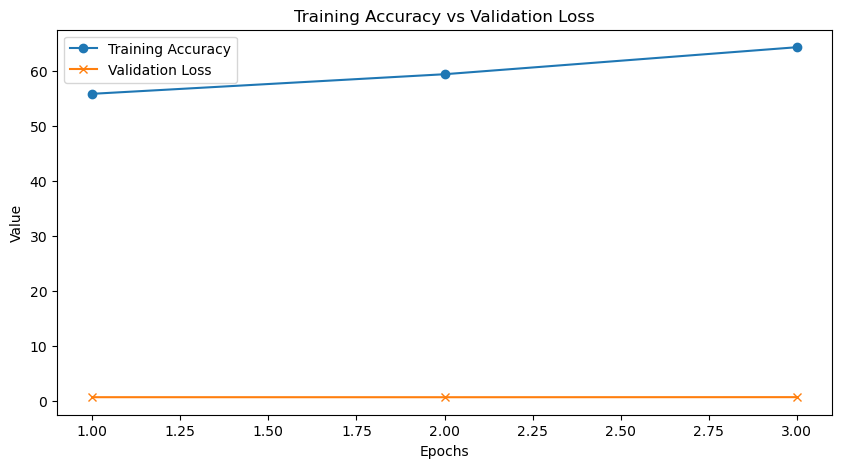

In [316]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_acc_history, label='Training Accuracy', marker='o')
plt.plot(epochs_range, valid_loss_history, label='Validation Loss', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Accuracy vs Validation Loss')
plt.legend()
plt.show()

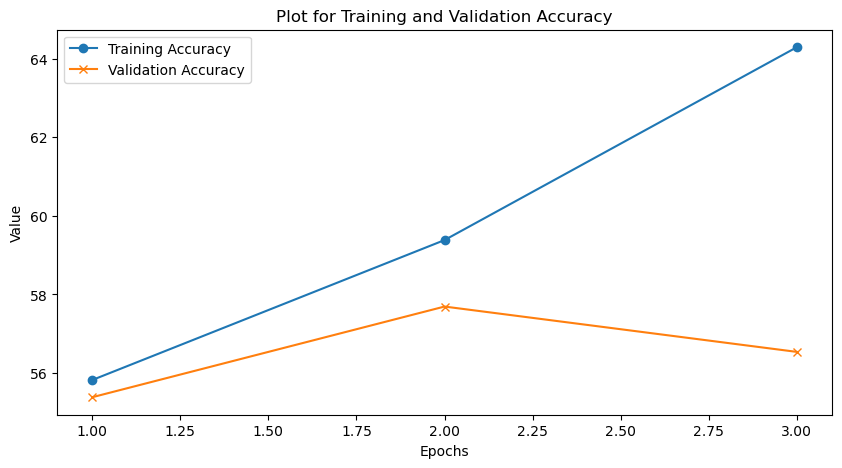

In [317]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_acc_history, label='Training Accuracy', marker='o')
plt.plot(epochs_range, valid_acc_history, label='Validation Accuracy', marker='x')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Plot for Training and Validation Accuracy')
plt.legend()
plt.show()

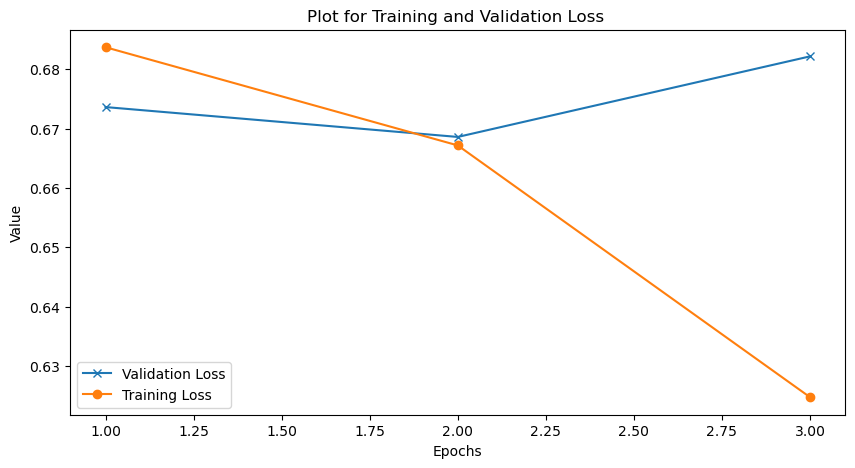

In [318]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10,5))
plt.plot(epochs_range, valid_loss_history, label='Validation Loss', marker='x')
plt.plot(epochs_range, train_loss_history, label='Training Loss', marker='o')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Plot for Training and Validation Loss ')
plt.legend()
plt.show()

In [319]:
'''
---------Model Saved after Training---------
'''
torch.save(model.state_dict(), "fine_tuned_model_nbs.pt")


In [320]:
dict=torch.load("fine_tuned_model_nbs.pt")


In [321]:
model = load_model()
model.load_state_dict(dict)
model.eval()

Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [322]:
nbs_.shape[0]

1299

In [323]:
nbs_opt=nbs_.iloc[:500]

Optimization

In [324]:

X_train_opt, X_test_opt = train_test_split(nbs_opt, test_size=0.2, random_state=42, stratify=nbs_opt['MultiModal_Label'])


In [325]:
import sys
!{sys.executable} -m pip install hyperopt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [326]:
from hyperopt import hp,STATUS_OK

space = {
    'LEARNING_RATE': hp.uniform('LEARNING_RATE', 1e-6, 5e-5),
    'batch_size': hp.choice('batch_size', [8,16,32]),
    'epoch': hp.quniform('epoch', 1,9,1),
    'threshold' : hp.uniform('threshold', 0.0, 1.0),
    'drop_proj' : hp.uniform('drop_proj', 0.0, 0.8),
    'drop_fus' : hp.uniform('drop_fus', 0.0, 0.8)
}

In [337]:
def obj_func(params):
    try:

        """Parameter"""

        batch_size = params['batch_size']
        epochs = int(params['epoch'])
        LEARNING_RATE = params['LEARNING_RATE']
        threshold = params['threshold']
        drop_proj = params['drop_proj']
        drop_fus = params['drop_fus']

        """Model Declaration"""
        model = load_model(drop_proj=drop_proj,drop_fus=drop_fus)
        model.eval()
        """DataLoader"""

        train_loader_dataset_opt = DATA(X_train_opt, text_tokenizer, image_transform)
        test_loader_dataset_opt = DATA(X_test_opt, text_tokenizer, image_transform)

        training_loader_opt = DataLoader(train_loader_dataset_opt, batch_size=batch_size, shuffle=True)
        val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)

        

        """Training"""

        for i in range(0,epochs):
            print(f'Epoch {i}')
            model,epoch_accu,epoch_loss = train(i, training_loader_opt,LEARNING_RATE,threshold)

        """Validation"""
        acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg,val_epoch_loss,all_preds,all_targets = valid(model,val_loader_opt,threshold)
        recall_deno = n_True_pos+n_False_neg                               
        recall = n_True_pos/recall_deno
        print(f"Recall : {recall}")

        Precision_dino = n_True_pos + n_False_pos                                                                                                                                                  
        Precision = n_True_pos/Precision_dino         
        f1=eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)
        loss = -(f1 - 0.2*abs(Precision-recall))
        return {'loss': loss,
                'status': STATUS_OK}
    except Exception as e:
        print("Exception:", e)
        return {'loss': 1.0, 'status': 'fail'}
    
    

In [338]:
from hyperopt import fmin, tpe, Trials



In [ ]:

trials = Trials()

best = fmin(
    fn=obj_func,
    space=space,
    algo=tpe.suggest,
    max_evals=15,
    trials=trials
)

print("Best hyperparameters:", best)

  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0                                               
  0%|          | 0/15 [00:01<?, ?trial/s, best loss=?]

0it [00:00, ?it/s]
/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),

/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),

1it [00:08,  8.86s/it]
2it [00:17,  8.56s/it]
3it [00:25,  8.26s/it]
4it [00:33,  8.20s/it]
5it [00:41,  8.17s/it]
6it [00:49,  8.15s/it]
7it [00:57,  8.08s/it]
8it [01:05,  8.19s/it]
9it [01:13,  8.08s/it]
10it [01:21,  8.00s/it]
11it [01:29,  7.93s/it]
12it [01:37,  7.96s/it]
13it [01:45,  8.

The Total Accuracy for TRaining Epoch 0:56.25         
Epoch 1                                               
  0%|          | 0/15 [03:24<?, ?trial/s, best loss=?]

...

0it [00:00, ?it/s]
1it [00:03,  3.68s/it]
2it [00:07,  3.65s/it]
3it [00:10,  3.64s/it]
4it [00:14,  3.64s/it]
5it [00:18,  3.73s/it]
6it [00:22,  3.68s/it]
7it [00:25,  3.70s/it]
8it [00:29,  3.65s/it]
9it [00:32,  3.65s/it]
10it [00:36,  3.65s/it]
11it [00:40,  3.72s/it]
12it [00:44,  3.69s/it]
13it [00:47,  3.65s/it]
14it [00:51,  3.60s/it]
15it [00:54,  3.58s/it]
16it [00:58,  3.59s/it]
17it [01:02,  3.62s/it]
18it [01:05,  3.66s/it]
19it [01:09,  3.64s/it]
20it [01:12,  3.63s/it]
21it [01:16,  3.64s/it]
22it [01:20,  3.60s/it]
23it [01:23,  3.60s/it]
24it [01:27,  3.58s/it]
25it [01:30,  3.61s/it]
26it [01:34,  3.63s/it]
27it [01:38,  3.68s/it]
28it [01:41,  3.63s/it]
29it [01:45,  3.70s/it]
30it [01:49,  3.66s/it]
31it [01:53,  3.68s/it]
32it [01:56,  3.64s/it]
33it [02:00,  3.63s/it]
34it [02:03,  3.60s/it]
35it [02:07,  3.58s/it]
36it [02:10,  3.59s/it]
37it [02:14,  3.59s/it]
38it [02:18,  3.63s/it]
39it [02:21,  3.62s/it]
40it [02:25,  3.64s/it]
41it [02:29,  3.62s/it]
42it [

The Total Accuracy for TRaining Epoch 0:76.5                                        
Epoch 1                                                                             
 20%|██        | 3/15 [46:38<2:36:00, 780.03s/trial, best loss: -0.6586189489345874]

0it [00:00, ?it/s]
1it [00:03,  3.71s/it]
2it [00:07,  3.64s/it]
3it [00:11,  3.67s/it]
4it [00:14,  3.64s/it]
5it [00:18,  3.65s/it]
6it [00:21,  3.61s/it]
7it [00:25,  3.61s/it]
8it [00:29,  3.69s/it]
9it [00:32,  3.67s/it]
10it [00:36,  3.61s/it]
11it [00:39,  3.61s/it]
12it [00:43,  3.61s/it]
13it [00:47,  3.60s/it]
14it [00:50,  3.58s/it]
15it [00:54,  3.58s/it]
16it [00:57,  3.59s/it]
17it [01:01,  3.58s/it]
18it [01:05,  3.63s/it]
19it [01:08,  3.58s/it]
20it [01:12,  3.58s/it]
21it [01:16,  3.65s/it]
22it [01:19,  3.63s/it]
23it [01:23,  3.61s/it]
24it [01:26,  3.63s/it]
25it [01:30,  3.75s/it]
26it [01:34,  3.72s/it]
27it [01:38,  3.69s/it]
28it [01:41,  3.69s/it]
29it [01:45,  3.66s/it]
30it [01:49,  3.67s/it]
31it [01:52,  3.66s/it]
32it [01:56,  3.62s/it]
33it [01:59,  3.59s/it]
34it [02:03,  3.60s/it]
35it [02:07,  3.63s/it]
36it [02:10,  3.66s/it]
37it [02:14,  3.64s/it]
38it [02:17,  3.59s/it]
39it [02:21,  3.58s/it]
40it [02:25,  3.60s/it]
41it [02:28,  3.61s/it]
42it [

The Total Accuracy for TRaining Epoch 1:81.0                                        
Epoch 2                                                                             
 20%|██        | 3/15 [49:40<2:36:00, 780.03s/trial, best loss: -0.6586189489345874]

0it [00:00, ?it/s]
1it [00:03,  3.78s/it]
2it [00:07,  3.69s/it]
3it [00:10,  3.64s/it]
4it [00:14,  3.64s/it]
5it [00:18,  3.71s/it]
6it [00:22,  3.68s/it]
7it [00:25,  3.64s/it]
8it [00:29,  3.64s/it]
9it [00:32,  3.64s/it]
10it [00:36,  3.67s/it]
11it [00:40,  3.69s/it]
12it [00:43,  3.66s/it]
13it [00:47,  3.63s/it]
14it [00:51,  3.62s/it]
15it [00:54,  3.61s/it]
16it [00:58,  3.60s/it]
17it [01:02,  3.64s/it]
18it [01:05,  3.63s/it]
19it [01:09,  3.68s/it]
20it [01:13,  3.65s/it]
21it [01:16,  3.65s/it]
22it [01:20,  3.61s/it]
23it [01:23,  3.60s/it]
24it [01:27,  3.61s/it]
25it [01:30,  3.58s/it]
26it [01:34,  3.59s/it]
27it [01:38,  3.63s/it]
28it [01:41,  3.65s/it]
29it [01:45,  3.61s/it]
30it [01:49,  3.60s/it]
31it [01:52,  3.64s/it]
32it [01:56,  3.65s/it]
33it [01:59,  3.62s/it]
34it [02:03,  3.68s/it]
35it [02:07,  3.64s/it]
36it [02:11,  3.66s/it]
37it [02:15,  3.86s/it]
38it [02:19,  4.01s/it]
39it [02:23,  3.92s/it]


In [330]:
batch_sizes = [8,16,32]   
batch_index = best['batch_size'] 
batch_size = batch_sizes[batch_index]  
epochs = int(best['epoch'])
LEARNING_RATE = best['LEARNING_RATE']
drop_proj = best['drop_proj']
drop_fus = best['drop_fus']
threshold = best['threshold']

print(f'Parameter we got which are best for out model are : batch_size= {batch_size},epochs= {epochs},LEARNING_RATE= {LEARNING_RATE},threshold= {threshold},drop_fus={drop_fus}')

Parameter we got which are best for out model are : batch_size= 32,epochs= 4,LEARNING_RATE= 1.2148109223915839e-05,threshold= 0.3595566606254288,drop_fus=0.16449789204607557


Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0


0it [00:00, ?it/s]/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(input_ids, dtype=torch.long),
/var/folders/m5/k9gs9x6n0v98jdqp3pn5nc5w0000gn/T/ipykernel_17200/3321296932.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
33it [08:37, 15.69s/it]


The Total Accuracy for TRaining Epoch 4:55.43792107795958
Epoch 0:
Training Accuracy : 55.43792107795958
Training Loss : 0.6856910604419131
Epoch 1


33it [08:44, 15.89s/it]


...

33it [08:36, 15.67s/it]


The Total Accuracy for TRaining Epoch 4:55.43792107795958
Epoch 3:
Training Accuracy : 55.43792107795958
Training Loss : 0.6677545417438854


9it [00:34,  3.85s/it]

validation Accuracy : 55.38461538461539
validation Loss : 0.6607054074605306
True Positives : 144
n_False_pos : 116
n_True_neg : 0
n_False_neg : 0


<Figure size 600x600 with 0 Axes>

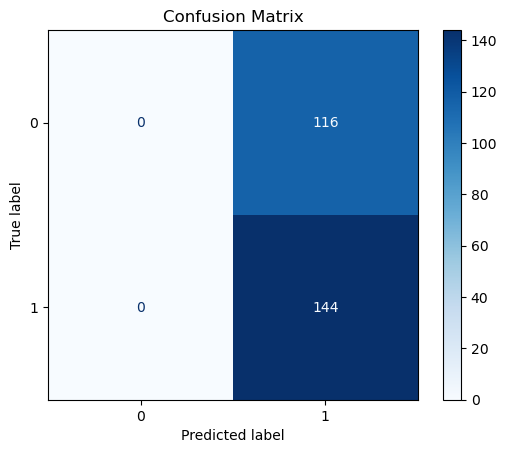

In [331]:
"""DataLoader"""

train_loader_dataset_opt = DATA(X_train, text_tokenizer, image_transform)
test_loader_dataset_opt = DATA(X_test, text_tokenizer, image_transform)

training_loader_opt = DataLoader(train_loader_dataset_opt, batch_size=batch_size, shuffle=True)
val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)

"""Model Initialization"""

model = load_model(drop_proj=drop_proj,drop_fus=drop_fus)
model.eval()
model.to(device)

for i in range(0,epochs):
            print(f'Epoch {i}')
            model,epoch_accu,epoch_loss = train(epochs, training_loader_opt,LEARNING_RATE,threshold)
            print(f'Epoch {i}:')
            print(f'Training Accuracy : {epoch_accu}')
            print(f'Training Loss : {epoch_loss}')

            train_acc_history.append(epoch_accu)
            train_loss_history.append(epoch_loss)

            
            
acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg,val_epoch_loss,all_preds,all_targets = valid(model,val_loader_opt,threshold)
print(f'validation Accuracy : {acc}')
print(f'validation Loss : {val_epoch_loss}')


print(f'True Positives : {n_True_pos}')
print(f'n_False_pos : {n_False_pos}')
print(f'n_True_neg : {n_True_neg}')
print(f'n_False_neg : {n_False_neg}')

plot_confusion_matrix(all_targets,all_preds)

In [332]:
print(f'F1 Score: {eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)}')

Recall : 1.0
Precision : 0.5538461538461539
F1 : 0.712871287128713
F1 Score: 0.712871287128713


In [333]:
torch.save(model.state_dict(), "fine_tuned_model_nbs.pt")


#Ref For Below : https://www.kaggle.com/code/aisuko/training-models-with-hyperparameters : Used the part for training the batch from the dataloader